 # **Introduction**
This notebook demonstrates how to fine-tune a pre-trained Transformer model (RoBERTa) for news topic classification using the AG News dataset. The goal is to train a model that can accurately classify news headlines and descriptions into one of four categories:

- World
- Sports
- Business
- Sci/Tech

We will follow the full machine learning pipeline:

Install required libraries and set up the environment.

1. Download and load the AG News dataset, and preprocess it.

2. Tokenize the text data using the Hugging Face transformers tokenizer.

3. Build and fine-tune a RoBERTa model for sequence classification.

4. Train the model on a subset of the data for efficiency.

5. Evaluate model performance using accuracy, classification report, and confusion matrix.

6. Make predictions on new, unseen news headlines.

This notebook provides a complete, working example of how to apply modern NLP models to real-world text classification tasks.

# **Install Required Libraries**

This cell installs the necessary Python packages:
- PyTorch (`torch`, `torchvision`, `torchaudio`) for deep learning
- Hugging Face `transformers` for working with pre-trained language models
- `pandas`, `scikit-learn`, `matplotlib`, `seaborn` for data manipulation and visualization


In [ ]:

!pip install numpy==1.25.2 torch==2.0.1 torchvision==0.15.2 torchaudio==2.0.2 --quiet
!pip install transformers==4.32.1 pandas scikit-learn matplotlib seaborn --quiet



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 619.9/619.9 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.1/317.1 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.0/21.0 MB 44.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.1/557.1 MB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.6/102.6 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.2

# **Restart Runtime**

After installing core packages, this cell restarts the Colab runtime to ensure all dependencies are properly loaded. You'll need to re-run all cells after this.


In [ ]:
import os
import IPython

# This will restart the runtime (you need to rerun everything after)
print("🔄 Restarting runtime...")
os.kill(os.getpid(), 9)


#  **Download AG News Dataset**

Downloads the AG News dataset (`train.csv` and `test.csv`) from a public GitHub repository. This dataset will be used for training and evaluating the text classification model.


In [ ]:
# Download raw CSVs from GitHub (same as Kaggle AG News)
!wget https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv -O train.csv
!wget https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/test.csv -O test.csv


## **Load and Preprocess Dataset**

- Loads the training and test data into pandas DataFrames.
- Adds column names (`label`, `title`, `description`).
- Creates a new column `text` by combining the `title` and `description`.
- Converts labels from the original 1–4 format to 0–3 to match model indexing.


In [ ]:
import pandas as pd

train_df = pd.read_csv("train.csv", header=None)
test_df = pd.read_csv("test.csv", header=None)

train_df.columns = ["label", "title", "description"]
test_df.columns = ["label", "title", "description"]

# Combine title + description and convert label from 1-4 → 0-3
train_df["text"] = train_df["title"] + " " + train_df["description"]
test_df["text"] = test_df["title"] + " " + test_df["description"]
train_df["label"] -= 1
test_df["label"] -= 1

print(train_df.head())


   label                                              title  \
0      2  Wall St. Bears Claw Back Into the Black (Reuters)   
1      2  Carlyle Looks Toward Commercial Aerospace (Reu...   
2      2    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3      2  Iraq Halts Oil Exports from Main Southern Pipe...   
4      2  Oil prices soar to all-time record, posing new...   

                                         description  \
0  Reuters - Short-sellers, Wall Street's dwindli...   
1  Reuters - Private investment firm Carlyle Grou...   
2  Reuters - Soaring crude prices plus worries\ab...   
3  Reuters - Authorities have halted oil export\f...   
4  AFP - Tearaway world oil prices, toppling reco...   

                                                text  
0  Wall St. Bears Claw Back Into the Black (Reute...  
1  Carlyle Looks Toward Commercial Aerospace (Reu...  
2  Oil and Economy Cloud Stocks' Outlook (Reuters...  
3  Iraq Halts Oil Exports from Main Southern Pipe...  
4  Oil pr

# **Tokenize and Prepare Dataset**

- Initializes the `roberta-base` tokenizer from Hugging Face.
- Defines a `NewsDataset` class that tokenizes the input texts and returns PyTorch tensors.
- Prepares `train_dataset` and `test_dataset` using the custom dataset class.


In [ ]:
from transformers import RobertaTokenizer
import torch
from torch.utils.data import Dataset

tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

class NewsDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(list(texts), padding=True, truncation=True, max_length=128, return_tensors="pt")
        self.labels = torch.tensor(labels.values, dtype=torch.long)  # ← fixed line

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)


train_dataset = NewsDataset(train_df["text"], train_df["label"])
test_dataset = NewsDataset(test_df["text"], test_df["label"])


/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

##  **Load RoBERTa Classification Model**

- Loads the pre-trained `roberta-base` model from Hugging Face with a classification head for 4 output labels.
- Moves the model to GPU (`cuda`) if available, otherwise defaults to CPU.


In [ ]:
from transformers import RobertaForSequenceClassification

model = RobertaForSequenceClassification.from_pretrained("roberta-base", num_labels=4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


/usr/local/lib/python3.11/dist-packages/huggingface_hub/file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.out_proj.bias', 'classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

# **Setup Training Loop**

- Samples 5,000 records from the training set to speed up training.
- Sets up data loaders for training and testing.
- Initializes the optimizer (`AdamW`) and loss function (`CrossEntropyLoss`).
- Defines a training loop that runs for 2 epochs, printing progress every 50 batches.


In [ ]:
from torch.utils.data import DataLoader
from transformers import AdamW
from torch import nn

#Reduce training data to 5,000 samples for speed
train_df_small = train_df.sample(n=5000, random_state=42).reset_index(drop=True)
train_dataset = NewsDataset(train_df_small["text"], train_df_small["label"])

# Loaders using the smaller dataset
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

# Optimizer and loss
optimizer = AdamW(model.parameters(), lr=2e-5)
criterion = nn.CrossEntropyLoss()

#  Training function with optional batch logging
def train(model, loader):
    model.train()
    total_loss = 0
    for i, batch in enumerate(loader):
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

        # Progress every 50 batches
        if i % 50 == 0:
            print(f"  Batch {i}/{len(loader)} - Loss: {loss.item():.4f}")

    print(f"\nEpoch Loss: {total_loss / len(loader):.4f}")

#  Train for 2 epochs
for epoch in range(2):
    print(f"\nEpoch {epoch+1}")
    train(model, train_loader)



Epoch 1
  Batch 0/313 - Loss: 0.1217
  Batch 50/313 - Loss: 0.1431
  Batch 100/313 - Loss: 0.3582
  Batch 150/313 - Loss: 0.2886
  Batch 200/313 - Loss: 0.0507
  Batch 250/313 - Loss: 0.0761
  Batch 300/313 - Loss: 0.0655

Epoch Loss: 0.1819

Epoch 2
  Batch 0/313 - Loss: 0.1190
  Batch 50/313 - Loss: 0.0425
  Batch 100/313 - Loss: 0.2630
  Batch 150/313 - Loss: 0.2917
  Batch 200/313 - Loss: 0.0972
  Batch 250/313 - Loss: 0.0631
  Batch 300/313 - Loss: 0.0393

Epoch Loss: 0.1209


# **Evaluate Model Performance**

- Defines the `evaluate()` function to calculate:
  - Accuracy
  - Classification Report
  - Confusion Matrix (visualized with Seaborn)
- Runs the evaluation on the test dataset using the trained model.


Accuracy: 0.9323684210526316

Classification Report:

              precision    recall  f1-score   support

       World       0.97      0.91      0.94      1900
      Sports       0.97      0.99      0.98      1900
    Business       0.93      0.87      0.90      1900
    Sci/Tech       0.86      0.96      0.91      1900

    accuracy                           0.93      7600
   macro avg       0.94      0.93      0.93      7600
weighted avg       0.94      0.93      0.93      7600



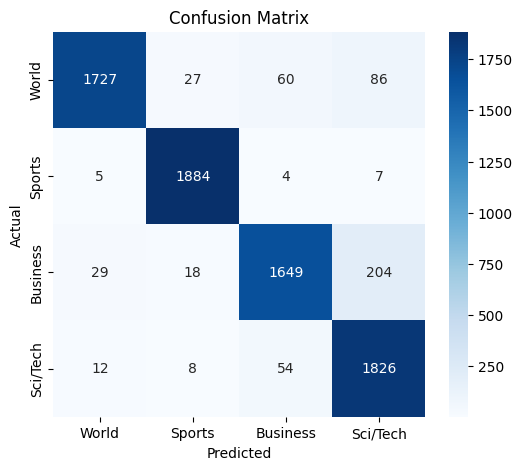

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def evaluate(model, loader):
    model.eval()
    predictions, truths = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, axis=1)

            predictions.extend(preds.cpu().numpy())
            truths.extend(labels.cpu().numpy())

    print("Accuracy:", accuracy_score(truths, predictions))
    print("\nClassification Report:\n")
    print(classification_report(truths, predictions, target_names=["World", "Sports", "Business", "Sci/Tech"]))

    cm = confusion_matrix(truths, predictions)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["World", "Sports", "Business", "Sci/Tech"], yticklabels=["World", "Sports", "Business", "Sci/Tech"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

evaluate(model, test_loader)


# **Make Predictions on New Samples**

- Defines a `predict()` function that:
  - Tokenizes new text samples
  - Runs the model in evaluation mode
  - Maps predicted label indices to actual category names
- Classifies three example news headlines into categories like `Sci/Tech`, `Sports`, etc.


In [ ]:
def predict(texts):
    model.eval()
    inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
        preds = torch.argmax(outputs.logits, dim=1)
    label_map = ["World", "Sports", "Business", "Sci/Tech"]
    return [label_map[i.item()] for i in preds]

predict([
    "NASA reveals new mission to explore Mars and beyond.",
    "Manchester United wins with a last-minute goal.",
    "Apple stock hits new high after earnings surprise."
])


['Sci/Tech', 'Sports', 'Sci/Tech']